In [22]:
import pandas as pd
from pathlib import Path

root = Path.cwd().parents[2]  # cwd is .../ProjectGroup5/src/data/True_power_generation_in_2022
                               # [0] = src/data, [1] = src, [2] = ProjectGroup5

df_orange = pd.read_csv(root / 'src/data/model_output/orange - model/orange_power_forecast_2022_daily_clean.csv')
df_actual = pd.read_csv(root / 'src/data/True_power_generation_in_2022/wind-2022-uur-data-reformated.csv')

print(df_orange.head())
print(df_actual.head())

         date  Orange Model - Predicted Wind Power (kWh)
0  2022-01-01                                   50790600
1  2022-01-02                                   85084000
2  2022-01-03                                   84636000
3  2022-01-04                                   40684600
4  2022-01-05                                   75801400
         date  Actual Energy created (kWh)
0  2022-01-01                     52426429
1  2022-01-02                     90462445
2  2022-01-03                     91356061
3  2022-01-04                     31857845
4  2022-01-05                     82969962


In [23]:
df_orange = df_orange.rename(columns={'Predicted Wind Power (kWh)': 'Orange Model - Predicted Wind Power (kWh)'})
df_actual = df_actual.rename(columns={df_actual.columns[1]: 'Actual Energy created (kWh)'})

df_merged = pd.merge(df_orange[['date', 'Orange Model - Predicted Wind Power (kWh)']],
                     df_actual[['date', 'Actual Energy created (kWh)']],
                     on='date', how='outer')

df_merged['date'] = pd.to_datetime(df_merged['date'])
df_merged = df_merged.sort_values('date').reset_index(drop=True)

df_merged.head(10)

,date,Orange Model - Predicted Wind Power (kWh),Actual Energy created (kWh)
0,2022-01-01,50790600,52426429
1,2022-01-02,85084000,90462445
2,2022-01-03,84636000,91356061
3,2022-01-04,40684600,31857845
4,2022-01-05,75801400,82969962
5,2022-01-06,23791000,32129473
6,2022-01-07,49120000,68788528
7,2022-01-08,45968400,63670564
8,2022-01-09,46748800,44554725
9,2022-01-10,5251100,2917080


In [24]:
df_merged.to_csv(root / 'src/data/True_power_generation_in_2022/Comparison_merged.csv', index=False)
print(f'Saved {len(df_merged)} rows')

Saved 365 rows


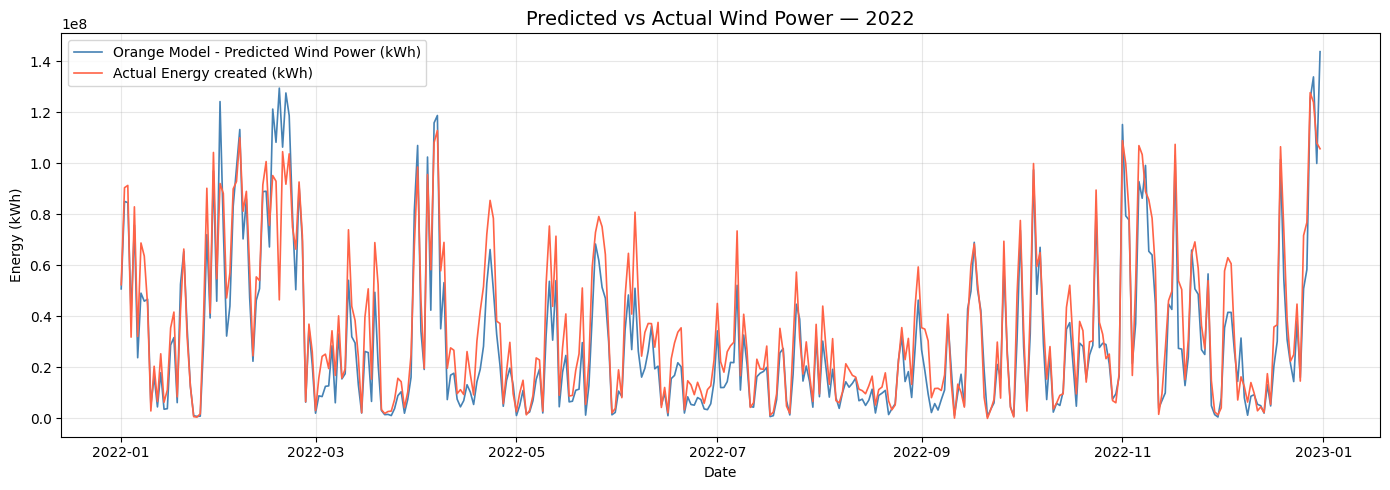

In [25]:
  import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_merged['date'], df_merged['Orange Model - Predicted Wind Power (kWh)'],
        color='steelblue', label='Orange Model - Predicted Wind Power (kWh)', linewidth=1.2)

ax.plot(df_merged['date'], df_merged['Actual Energy created (kWh)'],
        color='tomato', label='Actual Energy created (kWh)', linewidth=1.2)

ax.set_title('Predicted vs Actual Wind Power — 2022', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kWh)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

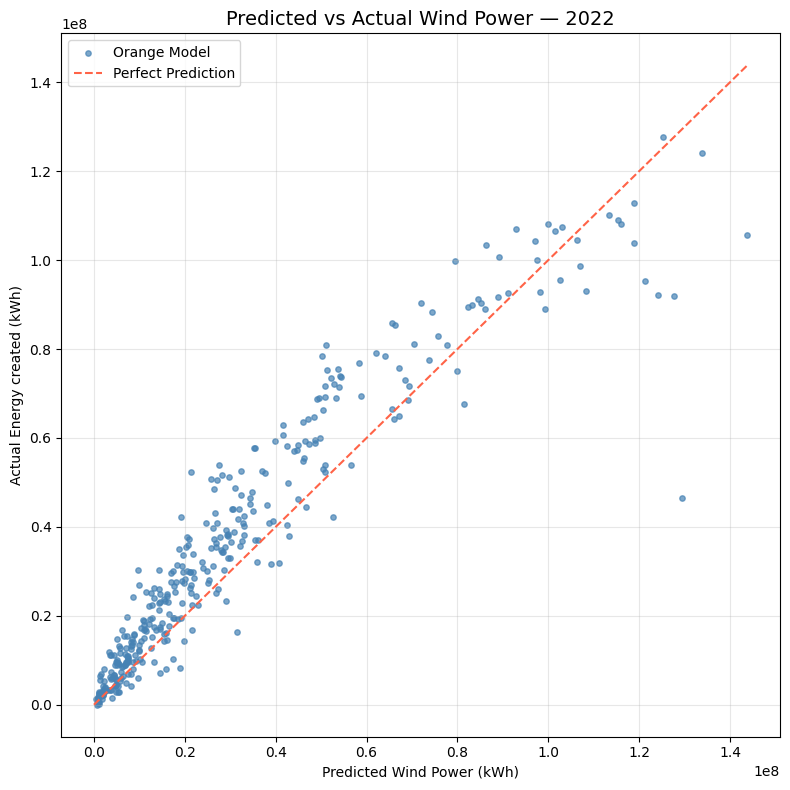

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df_merged['Orange Model - Predicted Wind Power (kWh)'],
           df_merged['Actual Energy created (kWh)'],
           color='steelblue', s=15, alpha=0.7, label='Orange Model')

# perfect prediction line (y = x)
min_val = df_merged[['Orange Model - Predicted Wind Power (kWh)', 'Actual Energy created (kWh)']].min().min()
max_val = df_merged[['Orange Model - Predicted Wind Power (kWh)', 'Actual Energy created (kWh)']].max().max()
ax.plot([min_val, max_val], [min_val, max_val], color='tomato', linewidth=1.5, linestyle='--', label='Perfect Prediction')

ax.set_title('Predicted vs Actual Wind Power — 2022', fontsize=14)
ax.set_xlabel('Predicted Wind Power (kWh)')
ax.set_ylabel('Actual Energy created (kWh)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()